<a href="https://www.kaggle.com/code/sonawanelalitsunil/egyptian-real-estate-listings-ml-31-51?scriptVersionId=262854004" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/egyptian-real-estate-listings/egypt_real_estate_listings.csv


## 🏡 Egyptian Real Estate Listings

## Detailed Description:
Discover a wide range of properties across Egypt, from luxurious villas along the Red Sea to modern apartments in Cairo and affordable family homes in emerging cities. Our real estate listings cover residential, commercial, and investment opportunities, complete with detailed pricing, location insights, and property features. Whether you’re buying, selling, or renting, explore verified listings that make finding your next home or investment in Egypt simple and reliable.

## import dataset

In [2]:
df= pd.read_csv("/kaggle/input/egyptian-real-estate-listings/egypt_real_estate_listings.csv")

In [3]:
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [4]:
df.tail()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
19919,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,500,000",Code: 2404\nChalet for sale in North Edge Towe...,"North Edge Towers, New Alamein City, Al Alamei...",Chalet,"1,259 sqft / 117 sqm",2,2,21 Aug 2025,Cash,NaN
19920,https://www.propertyfinder.eg/en/plp/buy/duple...,"24,000,000",Duplex for sale in Eastown -Sodic\n5th settlem...,"Eastown, 5th Settlement Compounds, The 5th Set...",Duplex,"2,756 sqft / 256 sqm",3+ Maid,4,1 Sep 2025,Cash,NaN
19921,https://www.propertyfinder.eg/en/plp/buy/chale...,"3,000,000",Chalet for Sale in One of the Prime Projects o...,"White Sand, Markaz Al Hamam, North Coast",Chalet,"1,195 sqft / 111 sqm",2,2,30 Jul 2025,Cash,NaN
19922,https://www.propertyfinder.eg/en/plp/buy/villa...,"9,500,000",Villa for sale in installments in Sarai Compou...,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",Villa,"2,573 sqft / 239 sqm",5,4,23 Aug 2025,Cash,NaN
19923,https://www.propertyfinder.eg/en/plp/buy/chale...,"7,500,000",Ground Chalet with Garden in Mountain View Nor...,"Mountain View, Qesm Ad Dabaah, North Coast",Chalet,990 sqft / 92 sqm,2,2,21 Aug 2025,Cash,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [6]:
df.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [7]:
df.dtypes

url               object
price             object
description       object
location          object
type              object
size              object
bedrooms          object
bathrooms         object
available_from    object
payment_method    object
down_payment      object
dtype: object

In [8]:
df.shape

(19924, 11)

In [9]:
df.isnull().sum()

url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['url', 'price', 'description', 'location', 'type', 'size', 'bedrooms',
       'bathrooms', 'available_from', 'payment_method', 'down_payment'],
      dtype='object')

## Data visualizations

In [12]:
def clean_numeric(x):
    try:
        # Remove any non-digit characters (like $, commas, etc.)
        import re
        cleaned = re.sub(r'[^0-9.]', '', str(x))
        return float(cleaned) if cleaned != '' else np.nan
    except Exception as e:
        return np.nan

# List of columns expected to be numeric
numeric_cols = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment']

# Apply cleaning function
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# Convert 'available_from' column to datetime
if 'available_from' in df.columns:
    df['available_from'] = pd.to_datetime(df['available_from'], errors='coerce')

# Check the data types after conversion
print('Data types after cleaning:')
print(df.dtypes)

# Display cleaned data
df.head()

Data types after cleaning:
url                       object
price                    float64
description               object
location                  object
type                      object
size                     float64
bedrooms                 float64
bathrooms                float64
available_from    datetime64[ns]
payment_method            object
down_payment             float64
dtype: object


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,8000000.0,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,73268.0,1.0,1.0,2025-08-31,Cash,1200000.0
1,https://www.propertyfinder.eg/en/plp/buy/villa...,25000000.0,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,2368220.0,4.0,4.0,2025-09-02,Cash,2100000.0
2,https://www.propertyfinder.eg/en/plp/buy/chale...,15135000.0,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,1270118.0,2.0,2.0,2025-08-19,Cash,1513000.0
3,https://www.propertyfinder.eg/en/plp/buy/apart...,12652000.0,Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,1787166.0,3.0,2.0,2025-08-26,Installments,1260000.0
4,https://www.propertyfinder.eg/en/plp/buy/villa...,45250000.0,Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,4306400.0,7.0,7.0,2025-09-02,Cash,2262500.0


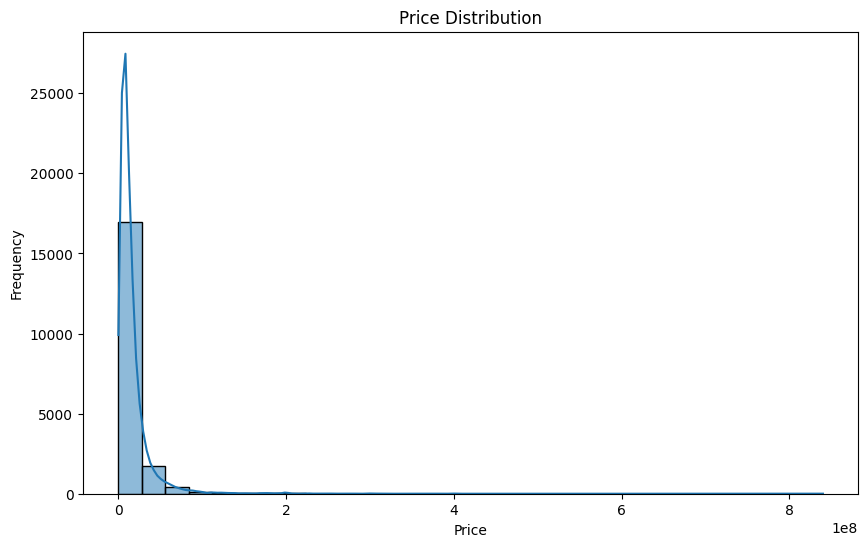

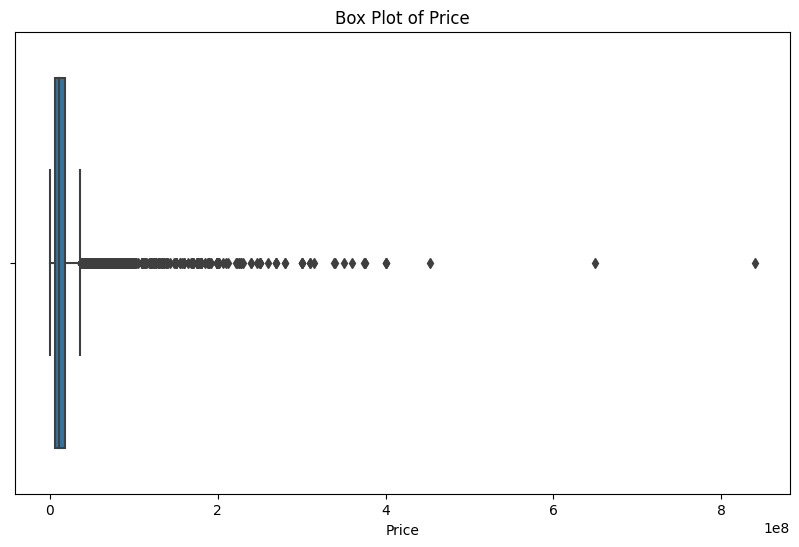

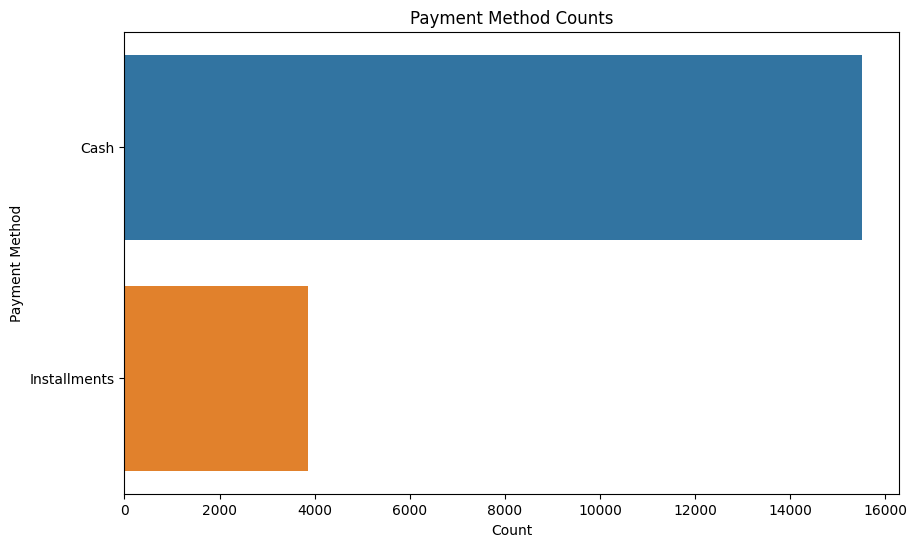

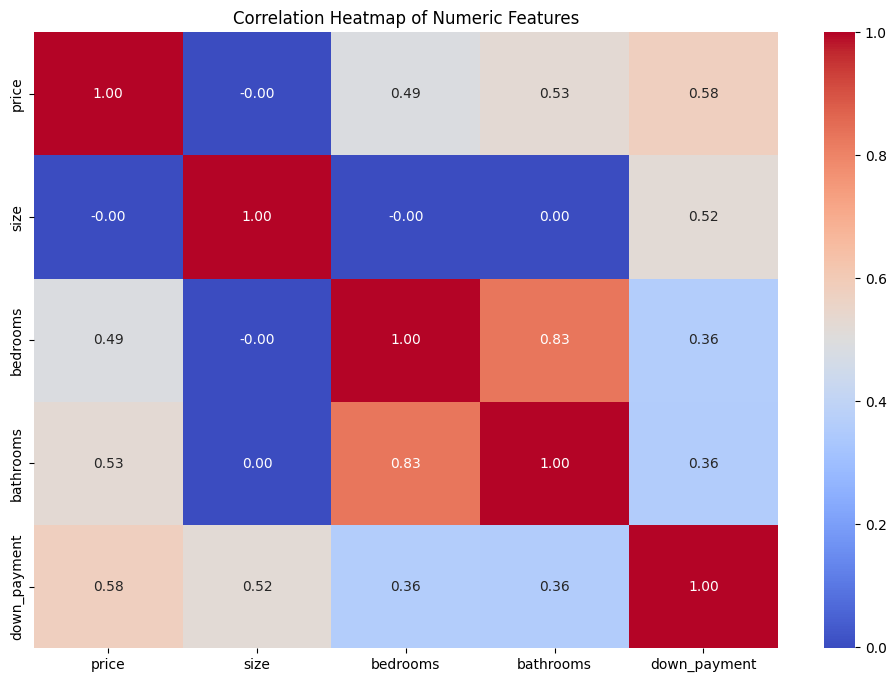

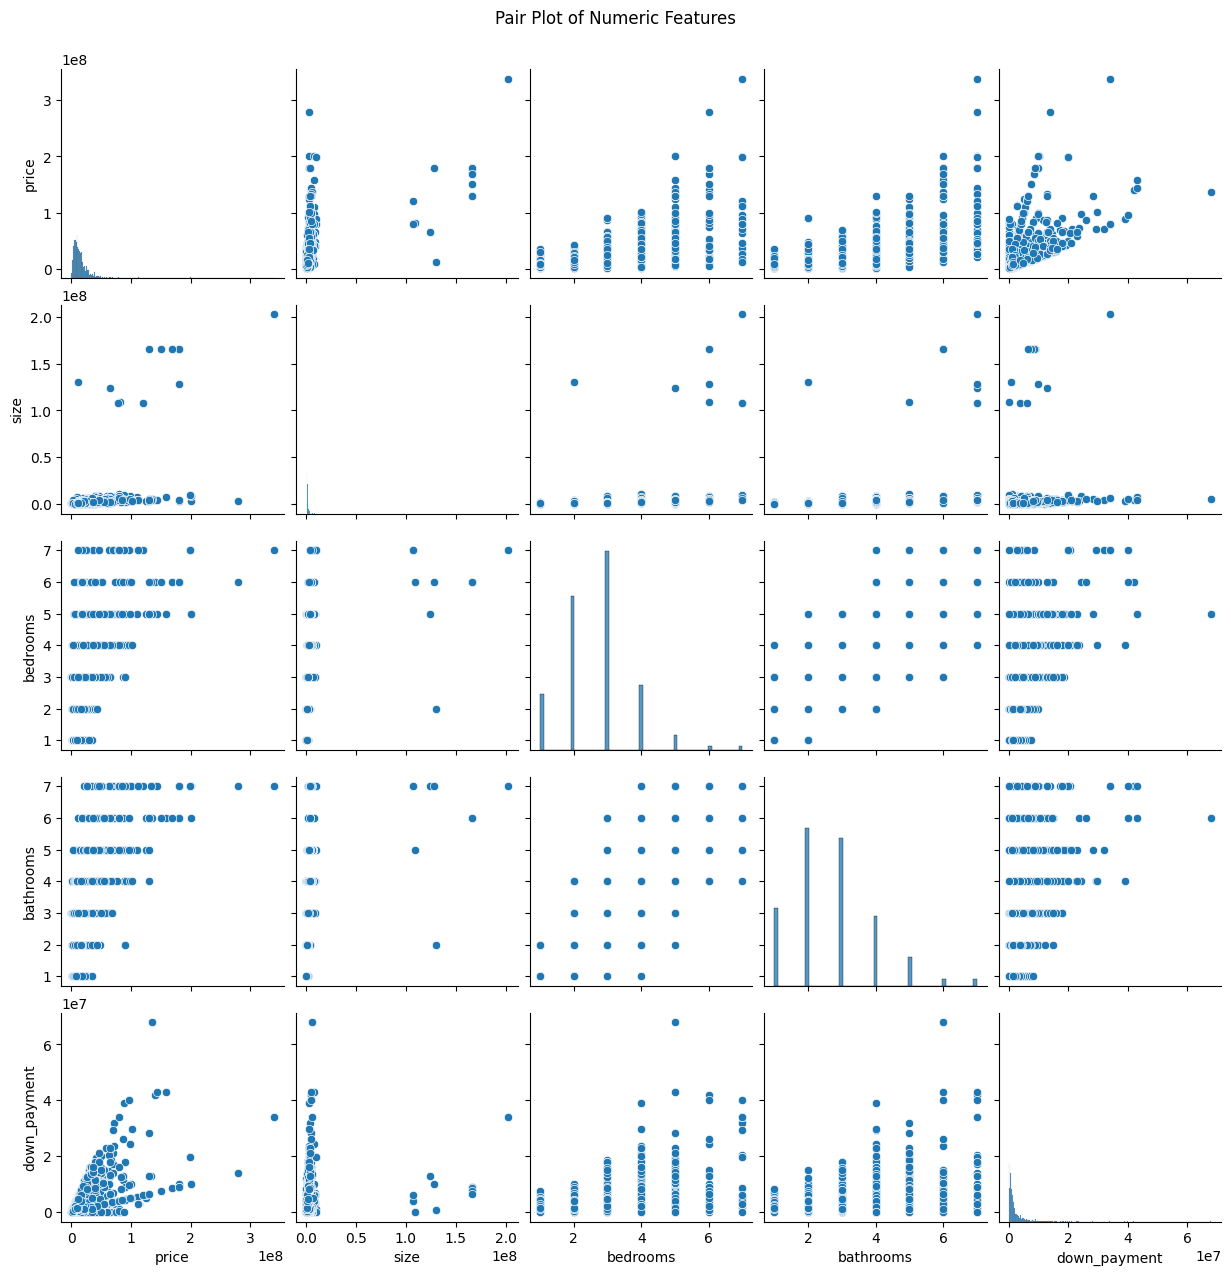

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Box plot for price
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

# Count plot (Pie Chart alternative) for payment_method
plt.figure(figsize=(10, 6))
sns.countplot(y='payment_method', data=df, order=df['payment_method'].value_counts().index)
plt.title('Payment Method Counts')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.show()

# Prepare numeric dataframe for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Pair Plot for numeric features
if numeric_df.shape[1] >= 2:
    sns.pairplot(numeric_df.dropna())
    plt.suptitle('Pair Plot of Numeric Features', y=1.02)
    plt.show()

## Predictive modeling

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Linear Regression Model R^2 Score: 0.3151240310959459


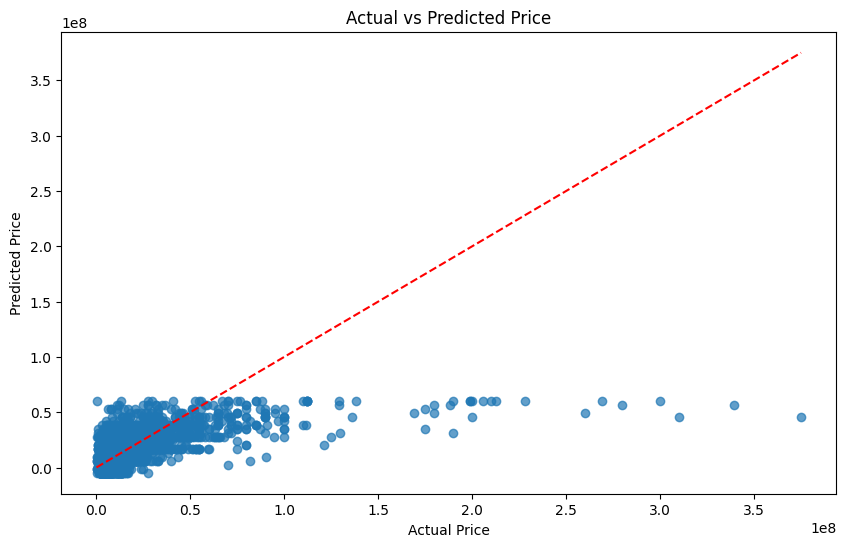

In [15]:
predictor_cols = ['size', 'bedrooms', 'bathrooms']
target = 'price'

# Drop rows with missing values in predictor columns or target
predictor_data = df[predictor_cols + [target]].dropna()

X = predictor_data[predictor_cols]
y = predictor_data[target]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the prediction accuracy using R^2 score
accuracy = r2_score(y_test, y_pred)
print('Linear Regression Model R^2 Score:', accuracy)

# Plot the true vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

## Thank you...pls upvote!!